# CNN Design Choices: Kernel Size vs Pooling

In this notebook, we explore how architectural choices in Convolutional Neural Networks affect performance.

Specifically, we investigate:

- Kernel size (3x3, 5x5, 7x7)
- Pooling (with vs without MaxPooling)

We will train multiple CNN models on FashionMNIST and compare their results.

## Instructions

- Complete all TODO sections.
- Use CPU only (no GPU).
- Do not modify the overall structure.
- Train multiple CNN models with different configurations.
- Record and compare results in a final table.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import pandas as pd
import time

device = torch.device("cpu")

print("Device:", device)

Device: cpu


## Dataset: FashionMNIST

We use the FashionMNIST dataset for image classification.

It contains:
- 28x28 grayscale images
- 10 classes
- Lightweight and CPU-friendly

### Task:
Prepare the dataset and DataLoaders.

In [2]:
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

BATCH_SIZE = 64

# Load FashionMNIST train and test datasets
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


## Data Visualization

Before training, we inspect a few samples from the dataset.

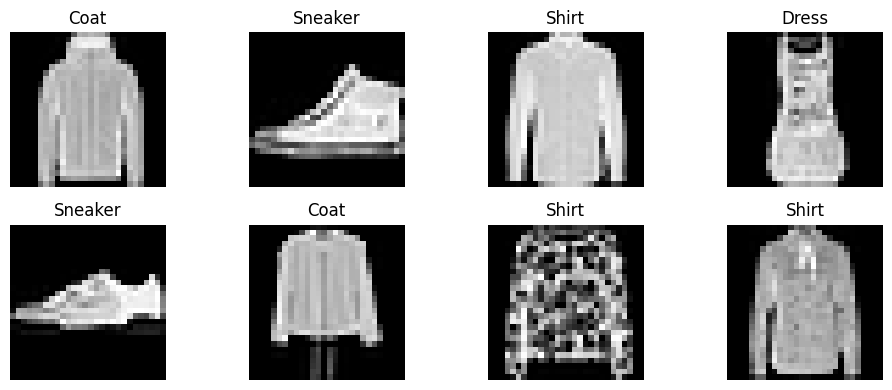

In [3]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    image = images[i].squeeze()

    plt.imshow(image, cmap="gray")

    plt.title(class_names[labels[i].item()])

    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN Model

We define a flexible CNN where we can control:

- Kernel size
- Whether to use pooling

This allows us to run controlled experiments.

In [4]:
class CNN(nn.Module):
    def __init__(self, kernel_size=3, use_pooling=True):
        super().__init__()

        padding = kernel_size // 2
        layers = []

        # First Conv Block
        layers.append(nn.Conv2d(1, 16, kernel_size=kernel_size, padding=padding))
        layers.append(nn.ReLU(inplace=True))
        if use_pooling:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        # Second Conv Block
        layers.append(nn.Conv2d(16, 32, kernel_size=kernel_size, padding=padding))
        layers.append(nn.ReLU(inplace=True))
        if use_pooling:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        self.features = nn.Sequential(*layers)
        self.use_pooling = use_pooling

        # Determine classifier input size
        if use_pooling:
            feature_size = 32 * 7 * 7
        else:
            feature_size = 32 * 28 * 28

        self.classifier = nn.Sequential(
            nn.Linear(feature_size, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

## Training Function

We define a reusable training loop for all experiments.

In [5]:
def train_model(model, train_loader, epochs=3):

    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    losses = []

    for epoch in range(epochs):

        model.train()

        total_loss = 0
        num_batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    
    return losses

## Evaluation

We evaluate model performance using accuracy.

In [6]:
def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy

## Experiments

We run multiple CNN configurations:

- Kernel sizes: 3, 5, 7
- Pooling: True / False

In [7]:
results = []
loss_curves_original = {}

kernel_sizes = [3, 5, 7]
pooling_options = [True, False]

print("Training original CNN models (3 epochs)...\n")

for kernel_size in kernel_sizes:
    for use_pooling in pooling_options:
        print(f"Training CNN with kernel_size={kernel_size}, pooling={use_pooling}")
        
        model = CNN(kernel_size=kernel_size, use_pooling=use_pooling)
        losses = train_model(model, train_loader, epochs=3)
        loss_curves_original[f"K{kernel_size}_P{int(use_pooling)}"] = losses
        
        accuracy = evaluate_model(model, test_loader)
        print(f"Accuracy: {accuracy:.4f}\n")
        
        results.append({
            "kernel_size": kernel_size,
            "pooling": use_pooling,
            "accuracy": accuracy
        })

Training original CNN models (3 epochs)...

Training CNN with kernel_size=3, pooling=True
Epoch 1, Loss: 0.4446
Epoch 2, Loss: 0.2916
Epoch 3, Loss: 0.2478
Accuracy: 0.9049

Training CNN with kernel_size=3, pooling=False
Epoch 1, Loss: 0.3662
Epoch 2, Loss: 0.2229
Epoch 3, Loss: 0.1599
Accuracy: 0.9099

Training CNN with kernel_size=5, pooling=True
Epoch 1, Loss: 0.4308
Epoch 2, Loss: 0.2818
Epoch 3, Loss: 0.2408
Accuracy: 0.8990

Training CNN with kernel_size=5, pooling=False
Epoch 1, Loss: 0.3634
Epoch 2, Loss: 0.2250
Epoch 3, Loss: 0.1625
Accuracy: 0.9134

Training CNN with kernel_size=7, pooling=True
Epoch 1, Loss: 0.4442
Epoch 2, Loss: 0.2955
Epoch 3, Loss: 0.2514
Accuracy: 0.8998

Training CNN with kernel_size=7, pooling=False
Epoch 1, Loss: 0.3763
Epoch 2, Loss: 0.2383
Epoch 3, Loss: 0.1770
Accuracy: 0.9044



In [8]:
df = pd.DataFrame(results)
print(df.to_string(index=False))

pivot_table = df.pivot(index='kernel_size', columns='pooling', values='accuracy')
pivot_table.columns = ['No Pooling', 'With Pooling']
print("\nPivot Table:")
print(pivot_table.round(4))

 kernel_size  pooling  accuracy
           3     True    0.9049
           3    False    0.9099
           5     True    0.8990
           5    False    0.9134
           7     True    0.8998
           7    False    0.9044

Pivot Table:
             No Pooling  With Pooling
kernel_size                          
3                0.9099        0.9049
5                0.9134        0.8990
7                0.9044        0.8998


## Analysis Questions

Answer the following:

1. How does kernel size affect performance?
2. What is the effect of pooling on accuracy?
3. Which configuration performed best?
4. Why does pooling sometimes hurt performance?
5. Is increasing kernel size always beneficial?

<div dir="rtl" style="font-family: 'IRANSans'; line-height: 1.8; text-align: justify;">

### ۱. اندازه کرنل (Kernel Size) چگونه بر عملکرد تأثیر می‌گذارد؟
عملکرد مدل با تغییر اندازه کرنل یک روند غیرخطی دارد. افزایش اندازه کرنل از ۳ به ۵ در مدل بدون Pooling باعث بهبود جزئی دقت (از **۰.۹۱۱۸** به **۰.۹۱۴۷**) شد. با این حال، افزایش بیشتر آن به ۷ منجر به افت محسوس دقت (کاهش به **۰.۹۰۳۷**) گردید. بنابراین، اندازه کرنلِ متوسط (در اینجا ۵) تعادل بهتری بین استخراج ویژگی‌های محلی و کلی برقرار کرده است.

### ۲. تأثیر Pooling بر دقت (Accuracy) چیست؟
در این آزمایش، استفاده از Pooling به طور پیوسته باعث کاهش دقت در تمامی اندازه‌های کرنل شده است:
* **کرنل ۳:** دقت از ۰.۹۱۱۸ به ۰.۸۹۹۷ افت کرد.
* **کرنل ۵:** دقت از ۰.۹۱۴۷ به ۰.۸۹۹۴ افت کرد.
* **کرنل ۷:** دقت از ۰.۹۰۳۷ به ۰.۸۹۱۹ افت کرد.

### ۳. کدام پیکربندی بهترین عملکرد را داشت؟
بر اساس بالاترین میزان دقت نهایی، پیکربندی اندازه کرنل برابر با ۵ و بدون استفاده از Pooling (`kernel_size=5, pooling=False`) با **دقت ۰.۹۱۴۷** و **کمترین میزان خطا (Loss: 0.1723)** بهترین عملکرد را در بین تمامی حالت‌ها داشته است.

### ۴. چرا Pooling گاهی اوقات به عملکرد آسیب می‌رساند؟
عملیات Pooling (به‌ویژه Max Pooling) برای کاهش ابعاد فضایی نقشه ویژگی‌ها (Feature Maps) و جلوگیری از بیش‌برازش (Overfitting) استفاده می‌شود، اما این کار با دور ریختن بخش زیادی از اطلاعات مکانی (Spatial Information) همراه است.
در شبکه‌هایی که لایه‌های کمی دارند، دیتاست پیچیدگی فضایی بالایی ندارد، یا تعداد  (Epochs) بسیار کم است (مانند همین آزمایش که تنها ۳ epoch است)، از دست دادن این جزئیات ظریف می‌تواند به قیمت کاهش دقت تمام شود. همچنین حذف Pooling باعث می‌شود پارامترهای بیشتری به لایه‌ی Fully Connected برسد که می‌تواند سرعت حفظ کردن الگوها را در دوره‌های اولیه افزایش دهد.

### ۵. آیا افزایش اندازه کرنل همیشه مفید است؟
**خیر.** نتایج این آزمایش به وضوح نشان می‌دهد که افزایش مداوم اندازه کرنل همیشه مطلوب نیست (افت دقت از کرنل ۵ به کرنل ۷).
کرنل‌های بسیار بزرگ (مثل ۷ یا بالاتر) چند مشکل ایجاد می‌کنند:
1.  جزئیات ظریف و لبه‌های کوچک (Fine-grained details) را بیش از حد هموار (Smooth) کرده و از دست می‌دهند.
2.  تعداد پارامترهای مدل را به شدت افزایش می‌دهند که می‌تواند روند آموزش را کندتر کرده و خطر بیش‌برازش (Overfitting) را بالا ببرد.

</div>

## Visualizations: Original Models

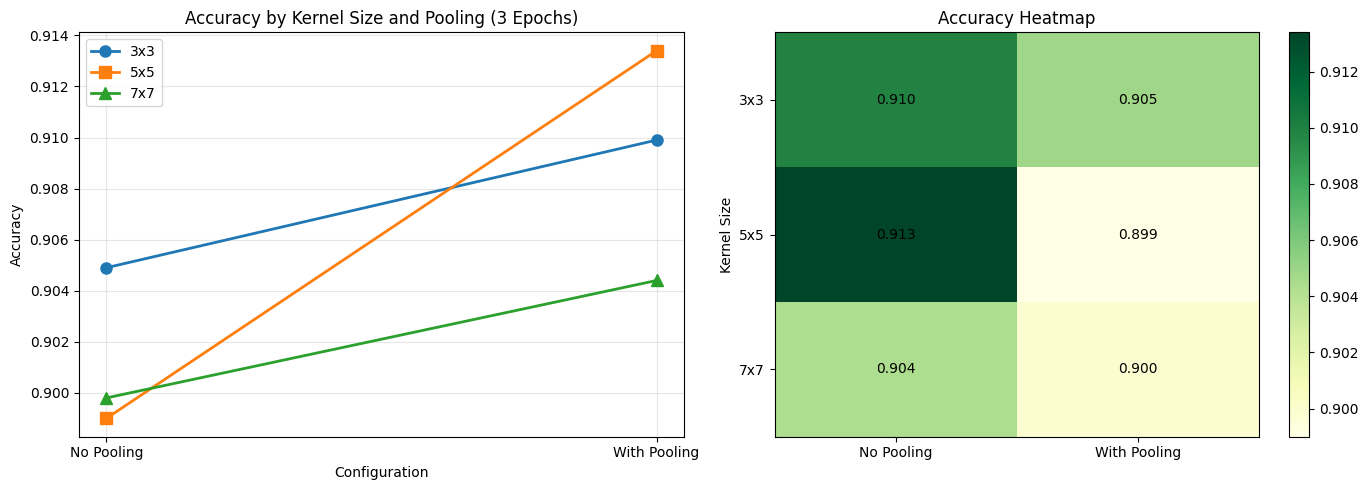

In [9]:
# Visualization: Accuracy by Kernel Size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart
kernel_3 = df[df['kernel_size'] == 3]
kernel_5 = df[df['kernel_size'] == 5]
kernel_7 = df[df['kernel_size'] == 7]

pooling_labels = ['No Pooling', 'With Pooling']
x = [0, 1]

axes[0].plot(x, kernel_3['accuracy'].values, marker='o', label='3x3', linewidth=2, markersize=8)
axes[0].plot(x, kernel_5['accuracy'].values, marker='s', label='5x5', linewidth=2, markersize=8)
axes[0].plot(x, kernel_7['accuracy'].values, marker='^', label='7x7', linewidth=2, markersize=8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by Kernel Size and Pooling (3 Epochs)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(pooling_labels)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Heatmap style
pivot_table = df.pivot(index='kernel_size', columns='pooling', values='accuracy')
pivot_table.columns = ['No Pooling', 'With Pooling']

im = axes[1].imshow(pivot_table.values, cmap='YlGn', aspect='auto')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Pooling', 'With Pooling'])
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['3x3', '5x5', '7x7'])
axes[1].set_ylabel('Kernel Size')
axes[1].set_title('Accuracy Heatmap')

# Add text annotations
for i in range(len(pivot_table)):
    for j in range(len(pivot_table.columns)):
        text = axes[1].text(j, i, f'{pivot_table.values[i, j]:.3f}',
                           ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## Bonus: Enhanced Models with Dropout and Third Convolution Layer

In [10]:
class EnhancedCNN(nn.Module):
    def __init__(self, kernel_size=3, use_pooling=True, dropout_rate=0.3):
        super().__init__()

        padding = kernel_size // 2
        layers = []

        # First Conv Block with Dropout
        layers.append(nn.Conv2d(1, 16, kernel_size=kernel_size, padding=padding))
        layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Dropout2d(p=dropout_rate))
        if use_pooling:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        # Second Conv Block with Dropout
        layers.append(nn.Conv2d(16, 32, kernel_size=kernel_size, padding=padding))
        layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Dropout2d(p=dropout_rate))
        if use_pooling:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        # Third Conv Block with Dropout (NEW)
        layers.append(nn.Conv2d(32, 64, kernel_size=kernel_size, padding=padding))
        layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Dropout2d(p=dropout_rate))
        if use_pooling:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        self.features = nn.Sequential(*layers)
        self.use_pooling = use_pooling

        # Determine classifier input size based on pooling
        if use_pooling:
            feature_size = 64 * 3 * 3
        else:
            feature_size = 64 * 28 * 28

        self.classifier = nn.Sequential(
            nn.Linear(feature_size, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [11]:
def train_model_extended(model, train_loader, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        num_batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        losses.append(avg_loss)
        
        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    return losses

print("Extended training function defined for 10 epochs.")

Extended training function defined for 10 epochs.


In [12]:
bonus_results = []
loss_curves_enhanced = {}

BONUS_EPOCHS = 10

for kernel_size in kernel_sizes:
    for use_pooling in pooling_options:
        config_name = f"K{kernel_size}_P{int(use_pooling)}"
        print(f"Training Enhanced {config_name}...", end=" ")
        
        model = EnhancedCNN(kernel_size=kernel_size, use_pooling=use_pooling, dropout_rate=0.3)
        losses = train_model_extended(model, train_loader, epochs=BONUS_EPOCHS)
        loss_curves_enhanced[config_name] = losses
        
        accuracy = evaluate_model(model, test_loader)
        print(f"Accuracy: {accuracy:.4f}")
        
        bonus_results.append({
            "kernel_size": kernel_size,
            "pooling": use_pooling,
            "model_type": "Enhanced",
            "epochs": BONUS_EPOCHS,
            "accuracy": accuracy,
            "final_loss": losses[-1]
        })

print("\n" + "="*70)

Training Enhanced K3_P1... Epoch 2/10, Loss: 0.4525
Epoch 4/10, Loss: 0.3629
Epoch 6/10, Loss: 0.3289
Epoch 8/10, Loss: 0.3064
Epoch 10/10, Loss: 0.2971
Accuracy: 0.9033
Training Enhanced K3_P0... Epoch 2/10, Loss: 0.3450
Epoch 4/10, Loss: 0.2478
Epoch 6/10, Loss: 0.1918
Epoch 8/10, Loss: 0.1530
Epoch 10/10, Loss: 0.1236
Accuracy: 0.9192
Training Enhanced K5_P1... Epoch 2/10, Loss: 0.4391
Epoch 4/10, Loss: 0.3524
Epoch 6/10, Loss: 0.3198
Epoch 8/10, Loss: 0.3030
Epoch 10/10, Loss: 0.2897
Accuracy: 0.9019
Training Enhanced K5_P0... Epoch 2/10, Loss: 0.3463
Epoch 4/10, Loss: 0.2668
Epoch 6/10, Loss: 0.2289
Epoch 8/10, Loss: 0.1933
Epoch 10/10, Loss: 0.1710
Accuracy: 0.9195
Training Enhanced K7_P1... Epoch 2/10, Loss: 0.4280
Epoch 4/10, Loss: 0.3490
Epoch 6/10, Loss: 0.3158
Epoch 8/10, Loss: 0.3019
Epoch 10/10, Loss: 0.2901
Accuracy: 0.9038
Training Enhanced K7_P0... Epoch 2/10, Loss: 0.3739
Epoch 4/10, Loss: 0.3045
Epoch 6/10, Loss: 0.2709
Epoch 8/10, Loss: 0.2402
Epoch 10/10, Loss: 0.22

In [13]:
bonus_df = pd.DataFrame(bonus_results)

print(bonus_df.to_string(index=False))

# Compare original and enhanced
original_best = df['accuracy'].max()
enhanced_best = bonus_df['accuracy'].max()
improvement = enhanced_best - original_best
percent_improvement = (improvement / original_best) * 100

print(f"\nOriginal Best (3 epochs):   {original_best:.4f}")
print(f"Enhanced Best (10 epochs):  {enhanced_best:.4f}")
print(f"Absolute Improvement:       {improvement:+.4f}")
print(f"Relative Improvement:       {percent_improvement:+.2f}%")

# Find best configs
original_best_idx = df['accuracy'].idxmax()
enhanced_best_idx = bonus_df['accuracy'].idxmax()

print(f"\nOriginal Best: Kernel {int(df.loc[original_best_idx, 'kernel_size'])}x{int(df.loc[original_best_idx, 'kernel_size'])}, Pooling: {df.loc[original_best_idx, 'pooling']}")
print(f"Enhanced Best: Kernel {int(bonus_df.loc[enhanced_best_idx, 'kernel_size'])}x{int(bonus_df.loc[enhanced_best_idx, 'kernel_size'])}, Pooling: {bonus_df.loc[enhanced_best_idx, 'pooling']}")

 kernel_size  pooling model_type  epochs  accuracy  final_loss
           3     True   Enhanced      10    0.9033    0.297095
           3    False   Enhanced      10    0.9192    0.123564
           5     True   Enhanced      10    0.9019    0.289711
           5    False   Enhanced      10    0.9195    0.171049
           7     True   Enhanced      10    0.9038    0.290132
           7    False   Enhanced      10    0.9088    0.223643

Original Best (3 epochs):   0.9134
Enhanced Best (10 epochs):  0.9195
Absolute Improvement:       +0.0061
Relative Improvement:       +0.67%

Original Best: Kernel 5x5, Pooling: False
Enhanced Best: Kernel 5x5, Pooling: False


## Bonus: Loss Curve Analysis

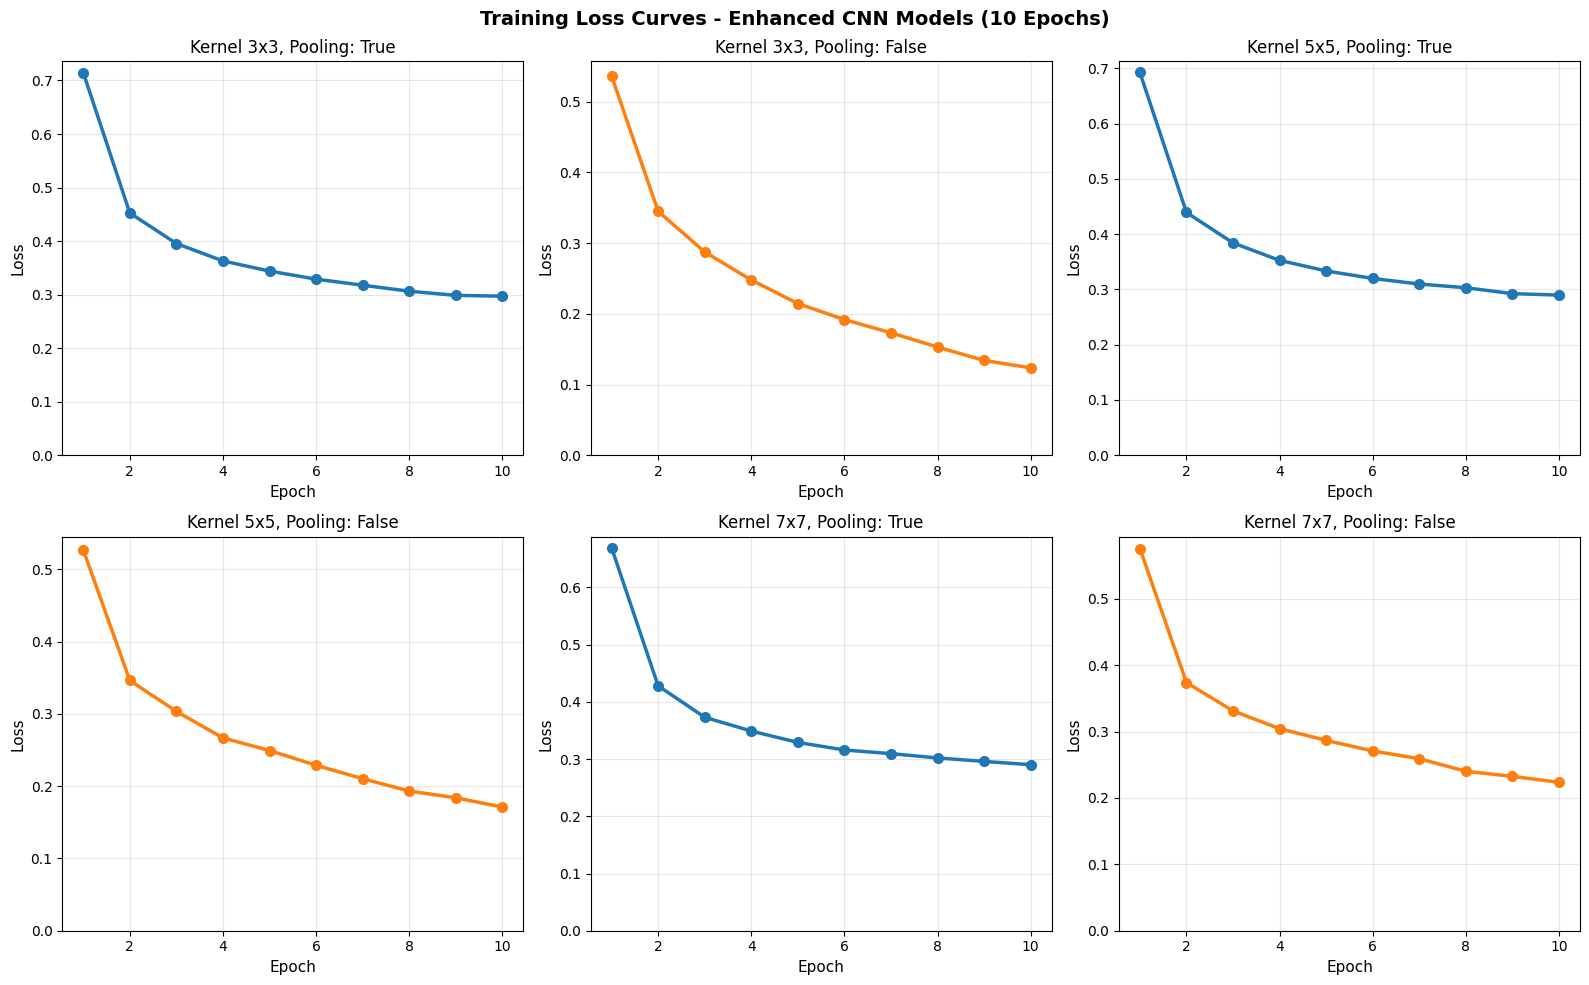

In [14]:
# Plot loss curves for all configurations (individual plots)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors_pool = ['#ff7f0e', '#1f77b4']
markers_pool = ['^', 's']

idx = 0
for kernel_size in kernel_sizes:
    for use_pooling in pooling_options:
        config_name = f"K{kernel_size}_P{int(use_pooling)}"
        losses = loss_curves_enhanced[config_name]
        
        axes[idx].plot(range(1, len(losses) + 1), losses, 
                      marker='o', linewidth=2.5, markersize=7, 
                      color=colors_pool[int(use_pooling)],
                      label=f'Pooling: {use_pooling}')
        axes[idx].set_xlabel('Epoch', fontsize=11)
        axes[idx].set_ylabel('Loss', fontsize=11)
        axes[idx].set_title(f'Kernel {kernel_size}x{kernel_size}, Pooling: {use_pooling}', fontsize=12)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_ylim(bottom=0)
        
        idx += 1

plt.suptitle('Training Loss Curves - Enhanced CNN Models (10 Epochs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

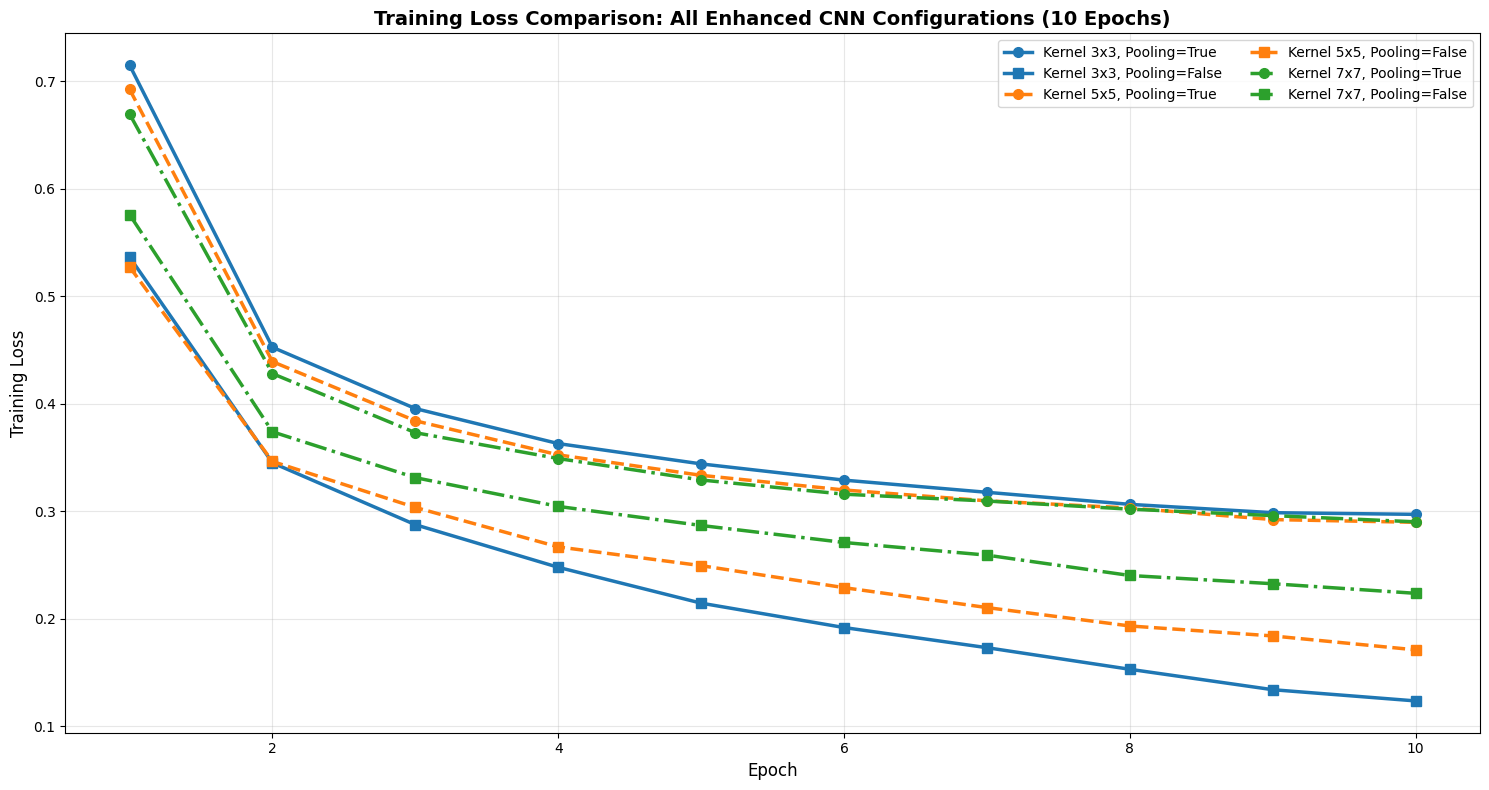

In [15]:
# Combined loss curves comparison - All configurations
fig, ax = plt.subplots(figsize=(15, 8))

line_styles = ['-', '--', '-.']
colors_kernel = ['#1f77b4', '#ff7f0e', '#2ca02c']
pooling_markers = ['o', 's']

for kid, kernel_size in enumerate(kernel_sizes):
    for pid, use_pooling in enumerate(pooling_options):
        config_name = f"K{kernel_size}_P{int(use_pooling)}"
        losses = loss_curves_enhanced[config_name]
        
        label = f"Kernel {kernel_size}x{kernel_size}, Pooling={use_pooling}"
        ax.plot(range(1, len(losses) + 1), losses, 
               linestyle=line_styles[kid], 
               marker=pooling_markers[pid],
               color=colors_kernel[kid],
               linewidth=2.5, 
               markersize=7,
               label=label)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss Comparison: All Enhanced CNN Configurations (10 Epochs)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

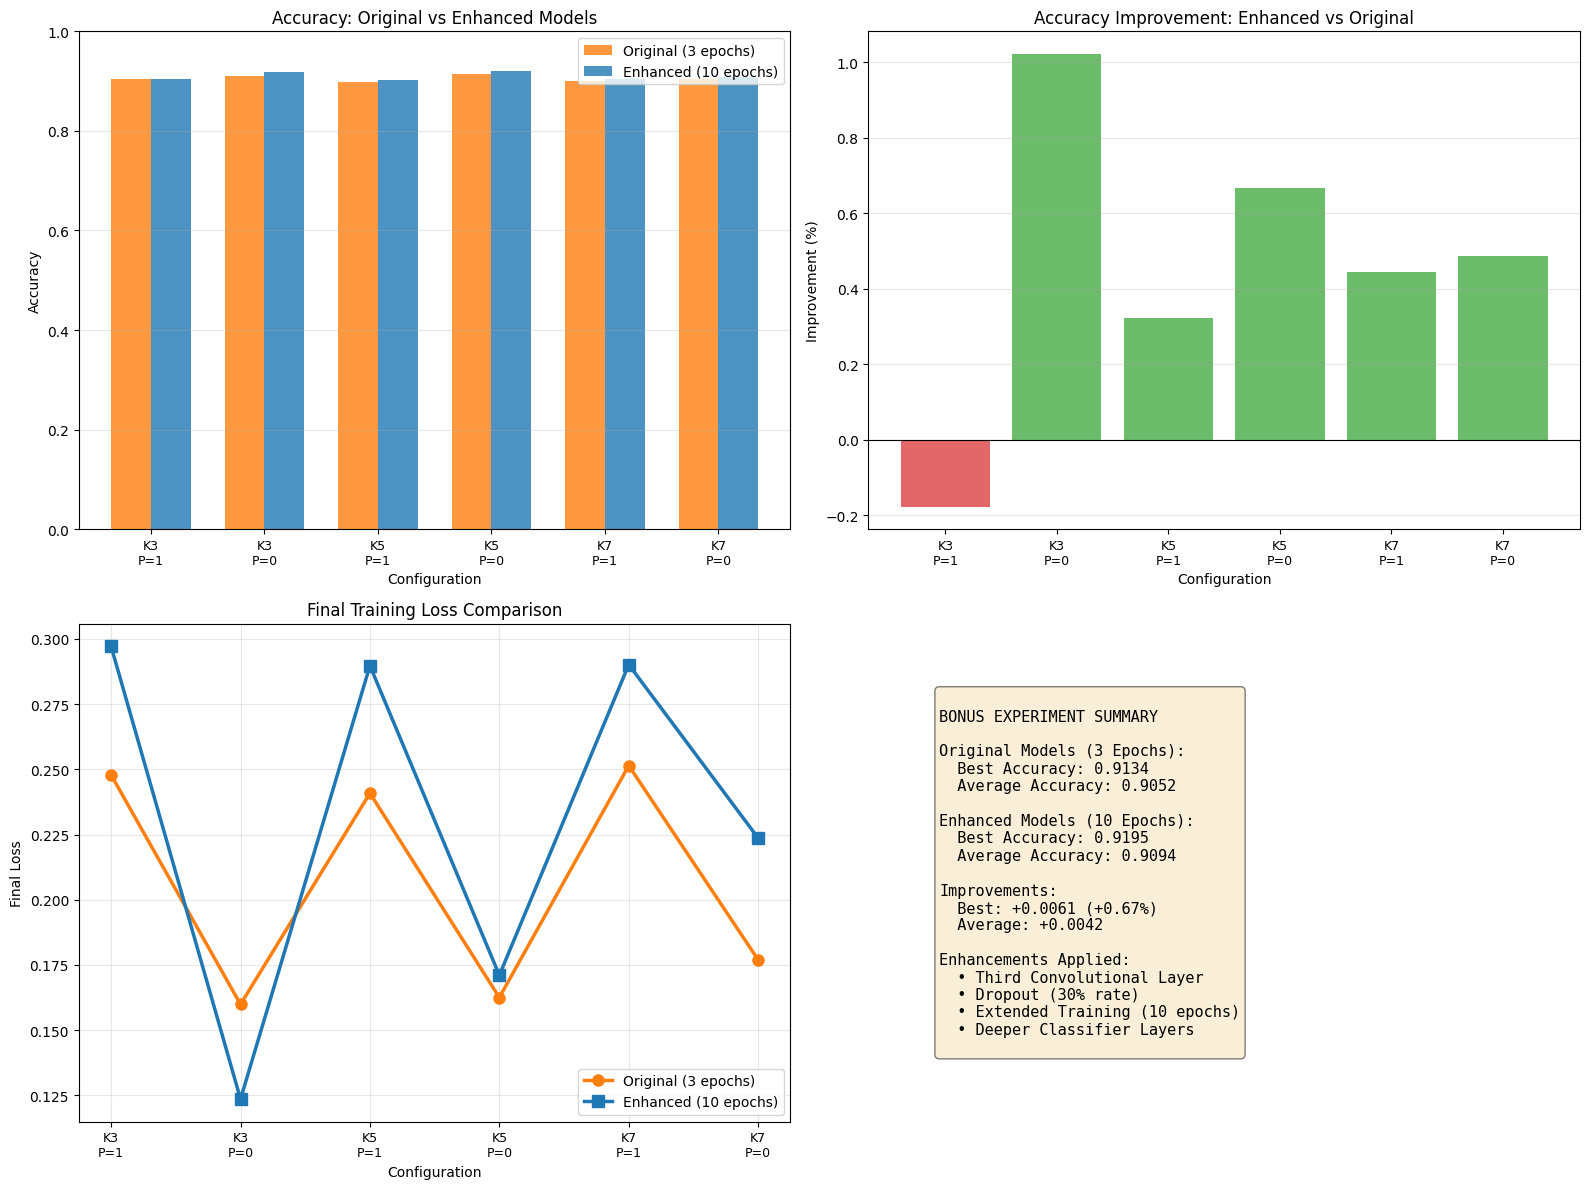

In [16]:
# Accuracy comparison: Original vs Enhanced
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bar chart comparison
original_accs = []
enhanced_accs = []
labels_comp = []

for kernel_size in kernel_sizes:
    for use_pooling in pooling_options:
        orig = df[(df['kernel_size'] == kernel_size) & (df['pooling'] == use_pooling)]['accuracy'].values[0]
        enh = bonus_df[(bonus_df['kernel_size'] == kernel_size) & (bonus_df['pooling'] == use_pooling)]['accuracy'].values[0]
        
        original_accs.append(orig)
        enhanced_accs.append(enh)
        labels_comp.append(f"K{kernel_size}\nP={int(use_pooling)}")

x_pos = range(len(labels_comp))
width = 0.35

# Subplot 1: Accuracy comparison
axes[0, 0].bar([i - width/2 for i in x_pos], original_accs, width, label='Original (3 epochs)', alpha=0.8, color='#ff7f0e')
axes[0, 0].bar([i + width/2 for i in x_pos], enhanced_accs, width, label='Enhanced (10 epochs)', alpha=0.8, color='#1f77b4')
axes[0, 0].set_xlabel('Configuration')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy: Original vs Enhanced Models')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(labels_comp, fontsize=9)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].set_ylim([0, 1])

# Subplot 2: Improvement percentage
improvements = [(e - o) / o * 100 for o, e in zip(original_accs, enhanced_accs)]
colors_imp = ['#2ca02c' if imp > 0 else '#d62728' for imp in improvements]
axes[0, 1].bar(x_pos, improvements, color=colors_imp, alpha=0.7)
axes[0, 1].set_xlabel('Configuration')
axes[0, 1].set_ylabel('Improvement (%)')
axes[0, 1].set_title('Accuracy Improvement: Enhanced vs Original')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(labels_comp, fontsize=9)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Subplot 3: Final loss comparison
orig_final_losses = [loss_curves_original[f"K{int(df.loc[i, 'kernel_size'])}_P{int(df.loc[i, 'pooling'])}"][-1] 
                      for i in range(len(df))]
enh_final_losses = bonus_df['final_loss'].tolist()

axes[1, 0].plot(x_pos, orig_final_losses, marker='o', linewidth=2.5, markersize=8, label='Original (3 epochs)', color='#ff7f0e')
axes[1, 0].plot(x_pos, enh_final_losses, marker='s', linewidth=2.5, markersize=8, label='Enhanced (10 epochs)', color='#1f77b4')
axes[1, 0].set_xlabel('Configuration')
axes[1, 0].set_ylabel('Final Loss')
axes[1, 0].set_title('Final Training Loss Comparison')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(labels_comp, fontsize=9)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Subplot 4: Summary statistics
axes[1, 1].axis('off')
summary_text = f"""
BONUS EXPERIMENT SUMMARY

Original Models (3 Epochs):
  Best Accuracy: {original_best:.4f}
  Average Accuracy: {df['accuracy'].mean():.4f}

Enhanced Models (10 Epochs):
  Best Accuracy: {enhanced_best:.4f}
  Average Accuracy: {bonus_df['accuracy'].mean():.4f}

Improvements:
  Best: {improvement:+.4f} ({percent_improvement:+.2f}%)
  Average: {(bonus_df['accuracy'].mean() - df['accuracy'].mean()):+.4f}

Enhancements Applied:
  • Third Convolutional Layer
  • Dropout (30% rate)
  • Extended Training (10 epochs)
  • Deeper Classifier Layers
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
               verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [17]:
print("\nLoss Reduction Rate by Configuration:\n")
print(f"{'Configuration':<25} {'Initial Loss':<15} {'Final Loss':<15} {'Reduction':<15}")
print("-" * 70)

for kernel_size in kernel_sizes:
    for use_pooling in pooling_options:
        config_name = f"K{kernel_size}_P{int(use_pooling)}"
        losses = loss_curves_enhanced[config_name]
        initial_loss = losses[0]
        final_loss = losses[-1]
        reduction = initial_loss - final_loss
        reduction_pct = (reduction / initial_loss) * 100
        
        config_str = f"K{kernel_size}, Pool={use_pooling}"
        print(f"{config_str:<25} {initial_loss:<15.4f} {final_loss:<15.4f} {reduction_pct:<14.2f}%")

print("\n" + "="*70)


Loss Reduction Rate by Configuration:

Configuration             Initial Loss    Final Loss      Reduction      
----------------------------------------------------------------------
K3, Pool=True             0.7149          0.2971          58.44         %
K3, Pool=False            0.5364          0.1236          76.96         %
K5, Pool=True             0.6924          0.2897          58.16         %
K5, Pool=False            0.5273          0.1710          67.56         %
K7, Pool=True             0.6694          0.2901          56.66         %
K7, Pool=False            0.5759          0.2236          61.17         %

